In [ ]:
! pip3 install tiktoken
import importlib
import tiktoken
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))
tokenizer = tiktoken.get_encoding("gpt2")


with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total number of character:", len(raw_text))
print(raw_text[:99])

tiktoken version: 0.11.0
Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))
enc_sample = enc_text[50:]
print(enc_sample)


context_size = 4 #length of the input
#The context_size of 4 means that the model is trained to look at a sequence of 4 words (or tokens)
#to predict the next word in the sequence.
#The input x is the first 4 tokens [1, 2, 3, 4], and the target y is the next 4 tokens [2, 3, 4, 5]

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y: {y}")

for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(context, "---->", desired)
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

5145
[290, 4920, 2241, 287, 257, 4489, 64, 319, 262, 34686, 41976, 13, 357, 10915, 314, 2138, 1807, 340, 561, 423, 587, 10598, 393, 28537, 2014, 198, 198, 1, 464, 6001, 286, 465, 13476, 1, 438, 5562, 373, 644, 262, 1466, 1444, 340, 13, 314, 460, 3285, 9074, 13, 46606, 536, 5469, 438, 14363, 938, 4842, 1650, 353, 438, 2934, 489, 3255, 465, 48422, 540, 450, 67, 3299, 13, 366, 5189, 1781, 340, 338, 1016, 284, 3758, 262, 1988, 286, 616, 4286, 705, 1014, 510, 26, 475, 314, 836, 470, 892, 286, 326, 11, 1770, 13, 8759, 2763, 438, 1169, 2994, 284, 943, 17034, 318, 477, 314, 892, 286, 526, 383, 1573, 11, 319, 9074, 13, 536, 5469, 338, 11914, 11, 33096, 663, 4808, 3808, 62, 355, 996, 484, 547, 12548, 287, 281, 13079, 410, 12523, 286, 22353, 13, 843, 340, 373, 407, 691, 262, 9074, 13, 536, 48819, 508, 25722, 276, 13, 11161, 407, 262, 40123, 18113, 544, 9325, 701, 11, 379, 262, 938, 402, 1617, 261, 12917, 905, 11, 5025, 502, 878, 402, 271, 10899, 338, 366, 31640, 12, 67, 20811, 1, 284, 910, 11, 35

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class DatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]





def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0, split=0.9): # Added 'split' here

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = DatasetV1(txt, tokenizer, max_length, stride)

    # # Create dataloader
    # dataloader = DataLoader(
    #     dataset,
    #     batch_size=batch_size,
    #     shuffle=shuffle,
    #     drop_last=drop_last,
    #     num_workers=num_workers
    # )

    # return dataloader
    train_size = int(split * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, tokenizer


# import torch
# print("PyTorch version:", torch.__version__)
# dataloader = create_dataloader_v1(
#     raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
# )

# data_iter = iter(dataloader)
# first_batch = next(data_iter)
# print(first_batch)
# second_batch = next(data_iter)
# print(second_batch)



# dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

# data_iter = iter(dataloader)
# inputs, targets = next(data_iter)
# print("Inputs:\n", inputs)
# print("\nTargets:\n", targets)

In [ ]:
class MyRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(MyRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.Wxh = nn.Linear(embedding_dim, hidden_dim)
        self.Whh = nn.Linear(hidden_dim, hidden_dim)
        self.Why = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        outputs, h = [], h_prev
        for t in range(embedded.size(1)):
            x_t = embedded[:, t, :]
            h = torch.tanh(self.Wxh(x_t) + self.Whh(h))
            y = self.Why(h)
            outputs.append(y.unsqueeze(1))
        return torch.cat(outputs, dim=1), h


In [ ]:
def train_model(model, train_loader, val_loader, vocab_size,
                num_epochs=10, lr=0.001, hidden_dim=128):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, correct, total = 0, 0, 0
        hidden = torch.zeros(train_loader.batch_size, hidden_dim).to(device)

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs, hidden = model(inputs, hidden.detach())

            loss = criterion(outputs.view(-1, vocab_size), targets.view(-1))
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=-1)
            correct += (preds == targets).sum().item()
            total += targets.numel()

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        hidden = torch.zeros(val_loader.batch_size, hidden_dim).to(device)
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs, hidden = model(inputs, hidden)
                loss = criterion(outputs.view(-1, vocab_size), targets.view(-1))
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=-1)
                correct += (preds == targets).sum().item()
                total += targets.numel()

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs


In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

train_loader, val_loader, tokenizer = create_dataloader_v1(
    raw_text, batch_size=16, max_length=32, stride=16, split=0.9 # 'split' is now a valid argument
)

vocab_size = tokenizer.n_vocab
embedding_dim, hidden_dim = 64, 128
model = MyRNN(vocab_size, embedding_dim, hidden_dim)

train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, vocab_size, num_epochs=20, lr=0.001, hidden_dim=hidden_dim
)

Epoch 1/20 | Train Loss: 10.5990, Train Acc: 0.0178 | Val Loss: 9.7704, Val Acc: 0.0703
Epoch 2/20 | Train Loss: 7.8528, Train Acc: 0.0296 | Val Loss: 6.5838, Val Acc: 0.0303
Epoch 3/20 | Train Loss: 6.1888, Train Acc: 0.0423 | Val Loss: 6.2389, Val Acc: 0.0391
Epoch 4/20 | Train Loss: 6.0607, Train Acc: 0.0586 | Val Loss: 6.2205, Val Acc: 0.0625
Epoch 5/20 | Train Loss: 6.0189, Train Acc: 0.0611 | Val Loss: 6.1780, Val Acc: 0.0742
Epoch 6/20 | Train Loss: 5.9755, Train Acc: 0.0640 | Val Loss: 6.1204, Val Acc: 0.0732
Epoch 7/20 | Train Loss: 5.9284, Train Acc: 0.0649 | Val Loss: 6.0714, Val Acc: 0.0820
Epoch 8/20 | Train Loss: 5.8728, Train Acc: 0.0792 | Val Loss: 6.0238, Val Acc: 0.0928
Epoch 9/20 | Train Loss: 5.7983, Train Acc: 0.0816 | Val Loss: 5.9516, Val Acc: 0.0996
Epoch 10/20 | Train Loss: 5.7124, Train Acc: 0.0885 | Val Loss: 5.8689, Val Acc: 0.1006
Epoch 11/20 | Train Loss: 5.6047, Train Acc: 0.0983 | Val Loss: 5.7933, Val Acc: 0.1172
Epoch 12/20 | Train Loss: 5.4796, Train 

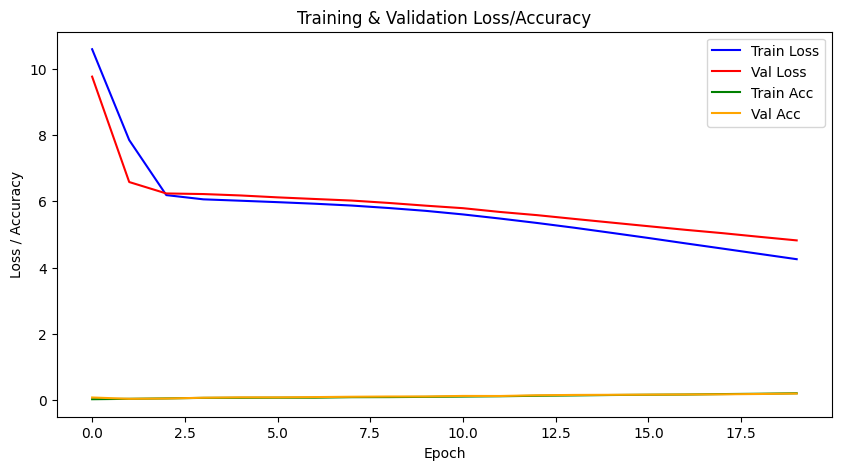

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Val Loss", color="red")
plt.plot(train_accs, label="Train Acc", color="green")
plt.plot(val_accs, label="Val Acc", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.title("Training & Validation Loss/Accuracy")
plt.legend()
plt.show()